In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/choudharyshweta/cyclist-trip-data-potfolio/cyclistic_trip_data_portfolio.csv


# Cyclistic Bike Share Analysis

## Understanding How Annual Members and Casual Riders Use Bikes Differently

Cyclistic is a bike-share company that wants to increase annual memberships.

This project analyzes historical bike trip data to understand differences between:
- Annual members
- Casual riders

The goal is to identify rider behavior patterns and provide recommendations to encourage casual riders to become annual members.

# Business Task

The main question for this analysis is:

**How do annual members and casual riders use Cyclistic bikes differently?**

The insights from this analysis will help Cyclistic develop strategies to increase annual memberships.

# Dataset Information

The dataset contains historical bike trip information including:

- Ride start time
- Ride end time
- Start station
- End station
- Bike type
- Rider type

The dataset was cleaned and analyzed using Python and Pandas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import os

os.listdir("/kaggle/input/datasets/choudharyshweta/cyclist-trip-data-potfolio")

['cyclistic_trip_data_portfolio.csv']

# Data Loading

The CSV file was imported into Python using Pandas.

In [5]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/choudharyshweta/cyclist-trip-data-potfolio/cyclistic_trip_data_portfolio.csv"
)

df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,0000000000000000,classic_bike,2025-02-28 22:50:00,2025-02-28 23:14:00,Navy Pier,S007,Streeter Dr & Grand Ave,S001,41.882147,-87.640859,41.884182,-87.642407,casual
1,0000000000000001,classic_bike,2025-01-11 18:15:00,2025-01-11 19:32:00,Michigan Ave & Oak St,S002,Wells St & Concord Ln,S004,41.888585,-87.642896,41.881443,-87.641178,casual
2,0000000000000002,classic_bike,2025-04-12 23:48:00,2025-04-13 00:16:00,Michigan Ave & Oak St,S002,Lake Shore Dr & Monroe St,S010,41.882060,-87.646804,41.884276,-87.643141,casual
3,0000000000000003,classic_bike,2025-03-07 19:46:00,2025-03-07 20:29:00,Wells St & Concord Ln,S004,Clark St & Lincoln Ave,S003,41.884488,-87.646090,41.880732,-87.645119,member
4,0000000000000004,electric_bike,2025-05-18 19:59:00,2025-05-18 20:47:00,Clark St & Lincoln Ave,S003,Union Station,S008,41.888755,-87.643137,41.886953,-87.645944,casual


# Data Exploration

The dataset was explored to understand:
- Number of rows and columns
- Available variables
- Data types
- Data quality

## Check Dataset Size

Checking the dataset size helps determine how many bike trips and variables are available for analysis.

In [6]:
df.shape

(5000, 13)

## Check Column Names

Reviewing column names helps understand what information is available in the dataset.

In [7]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')

## Check Data Types and Information

The dataset information was reviewed to identify:
- Column data types
- Number of non-null values
- Potential data quality issues

This step helps determine which columns require cleaning or formatting.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ride_id             5000 non-null   object 
 1   rideable_type       5000 non-null   object 
 2   started_at          5000 non-null   object 
 3   ended_at            5000 non-null   object 
 4   start_station_name  4848 non-null   object 
 5   start_station_id    4840 non-null   object 
 6   end_station_name    4851 non-null   object 
 7   end_station_id      4838 non-null   object 
 8   start_lat           5000 non-null   float64
 9   start_lng           5000 non-null   float64
 10  end_lat             5000 non-null   float64
 11  end_lng             5000 non-null   float64
 12  member_casual       5000 non-null   object 
dtypes: float64(4), object(9)
memory usage: 507.9+ KB


## Check Missing Values

Missing values were checked to identify incomplete records.

Understanding missing data helps determine whether additional cleaning steps are required before analysis.

In [9]:
df.isnull().sum()

ride_id                 0
rideable_type           0
started_at              0
ended_at                0
start_station_name    152
start_station_id      160
end_station_name      149
end_station_id        162
start_lat               0
start_lng               0
end_lat                 0
end_lng                 0
member_casual           0
dtype: int64

## Check Duplicate Records

Duplicate records were identified because repeated trips could affect analysis results.

Removing duplicates helps improve data accuracy.

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['started_at'] = pd.to_datetime(df['started_at'])

df['ended_at'] = pd.to_datetime(df['ended_at'])

## Check Data Types and Information

The dataset information was reviewed to identify:
- Column data types
- Number of non-null values
- Potential data quality issues

This step helps determine which columns require cleaning or formatting.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ride_id             5000 non-null   object        
 1   rideable_type       5000 non-null   object        
 2   started_at          5000 non-null   datetime64[ns]
 3   ended_at            5000 non-null   datetime64[ns]
 4   start_station_name  4848 non-null   object        
 5   start_station_id    4840 non-null   object        
 6   end_station_name    4851 non-null   object        
 7   end_station_id      4838 non-null   object        
 8   start_lat           5000 non-null   float64       
 9   start_lng           5000 non-null   float64       
 10  end_lat             5000 non-null   float64       
 11  end_lng             5000 non-null   float64       
 12  member_casual       5000 non-null   object        
dtypes: datetime64[ns](2), float64(4), object(7)
memo

In [13]:
df['ride_length'] = (
    df['ended_at'] - df['started_at']
).dt.total_seconds()/60

## View Sample Records

The first few rows of the dataset were displayed to verify that the data was loaded correctly and to understand the format of each variable.

In [14]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length
0,0000000000000000,classic_bike,2025-02-28 22:50:00,2025-02-28 23:14:00,Navy Pier,S007,Streeter Dr & Grand Ave,S001,41.882147,-87.640859,41.884182,-87.642407,casual,24.0
1,0000000000000001,classic_bike,2025-01-11 18:15:00,2025-01-11 19:32:00,Michigan Ave & Oak St,S002,Wells St & Concord Ln,S004,41.888585,-87.642896,41.881443,-87.641178,casual,77.0
2,0000000000000002,classic_bike,2025-04-12 23:48:00,2025-04-13 00:16:00,Michigan Ave & Oak St,S002,Lake Shore Dr & Monroe St,S010,41.882060,-87.646804,41.884276,-87.643141,casual,28.0
3,0000000000000003,classic_bike,2025-03-07 19:46:00,2025-03-07 20:29:00,Wells St & Concord Ln,S004,Clark St & Lincoln Ave,S003,41.884488,-87.646090,41.880732,-87.645119,member,43.0
4,0000000000000004,electric_bike,2025-05-18 19:59:00,2025-05-18 20:47:00,Clark St & Lincoln Ave,S003,Union Station,S008,41.888755,-87.643137,41.886953,-87.645944,casual,48.0


## Check Dataset Size

The dataset size was reviewed to determine the total number of bike trips and available columns.

This helps understand the scope of the analysis.

In [15]:
df[df['ride_length'] <= 0].shape

(0, 14)

In [16]:
df = df[df['ride_length'] > 0]

df.shape

(5000, 14)

# Data Cleaning

Before analyzing the Cyclistic bike-share data, the dataset needs to be cleaned and prepared.

The cleaning process includes:

- Checking and handling duplicate records
- Converting date and time columns into the correct format
- Creating new variables for analysis
- Removing invalid ride records

These steps help improve data quality and ensure accurate analysis results.

## Check for Duplicate Records

Duplicate records can affect the accuracy of analysis. 
The dataset was checked for duplicate rows before further processing.

In [17]:
df.duplicated().sum()

np.int64(0)

## Remove Duplicate Records

Duplicate records can affect the accuracy of the analysis by counting the same bike trip more than once.

After identifying duplicate rows, duplicate records are removed to ensure each trip is represented only once.

In [18]:
df = df.drop_duplicates()

df.shape

(5000, 14)

## Convert Date and Time Columns

The ride start and end time columns are converted into datetime format.

This allows further analysis of:
- Ride duration
- Daily riding patterns
- Monthly trends
- Seasonal changes

In [19]:
df['started_at'] = pd.to_datetime(df['started_at'])

df['ended_at'] = pd.to_datetime(df['ended_at'])

## Verify Date Conversion

The data types are checked again to confirm that the start and end time columns have been successfully converted to datetime format.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ride_id             5000 non-null   object        
 1   rideable_type       5000 non-null   object        
 2   started_at          5000 non-null   datetime64[ns]
 3   ended_at            5000 non-null   datetime64[ns]
 4   start_station_name  4848 non-null   object        
 5   start_station_id    4840 non-null   object        
 6   end_station_name    4851 non-null   object        
 7   end_station_id      4838 non-null   object        
 8   start_lat           5000 non-null   float64       
 9   start_lng           5000 non-null   float64       
 10  end_lat             5000 non-null   float64       
 11  end_lng             5000 non-null   float64       
 12  member_casual       5000 non-null   object        
 13  ride_length         5000 non-null   float64     

## Calculate Ride Duration

A new column called **ride_length** is created to calculate how long each bike trip lasted.

The duration is calculated in minutes by finding the difference between the ride start time and end time.

In [21]:
df['ride_length'] = (
    df['ended_at'] - df['started_at']
).dt.total_seconds()/60

## Review Ride Duration

The first few records are reviewed to confirm that the new ride_length column was created correctly.

In [22]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length
0,0000000000000000,classic_bike,2025-02-28 22:50:00,2025-02-28 23:14:00,Navy Pier,S007,Streeter Dr & Grand Ave,S001,41.882147,-87.640859,41.884182,-87.642407,casual,24.0
1,0000000000000001,classic_bike,2025-01-11 18:15:00,2025-01-11 19:32:00,Michigan Ave & Oak St,S002,Wells St & Concord Ln,S004,41.888585,-87.642896,41.881443,-87.641178,casual,77.0
2,0000000000000002,classic_bike,2025-04-12 23:48:00,2025-04-13 00:16:00,Michigan Ave & Oak St,S002,Lake Shore Dr & Monroe St,S010,41.882060,-87.646804,41.884276,-87.643141,casual,28.0
3,0000000000000003,classic_bike,2025-03-07 19:46:00,2025-03-07 20:29:00,Wells St & Concord Ln,S004,Clark St & Lincoln Ave,S003,41.884488,-87.646090,41.880732,-87.645119,member,43.0
4,0000000000000004,electric_bike,2025-05-18 19:59:00,2025-05-18 20:47:00,Clark St & Lincoln Ave,S003,Union Station,S008,41.888755,-87.643137,41.886953,-87.645944,casual,48.0


## Remove Invalid Trips

Trips with zero or negative ride duration are considered invalid because they do not represent actual bike rides.

These records are removed to improve the accuracy of the analysis.

In [23]:
df[df['ride_length'] <= 0].shape

(0, 14)

In [24]:
df = df[df['ride_length'] > 0]

df.shape

(5000, 14)

# Data Analysis

After cleaning the dataset, the next step is to analyze rider behavior patterns.

The analysis focuses on understanding the differences between:
- Annual members
- Casual riders

The following questions will be explored:

- How many rides are taken by each rider type?
- Do members and casual riders have different ride durations?
- Are there differences in riding patterns throughout the week?
- What insights can help increase annual memberships?

## Number of Rides by Rider Type

The number of rides taken by annual members and casual riders is calculated to understand the distribution of users.

In [25]:
df['member_casual'].value_counts()

member_casual
member    2504
casual    2496
Name: count, dtype: int64

## Visualize Rides by Rider Type

A bar chart is created to compare the total number of rides between annual members and casual riders.

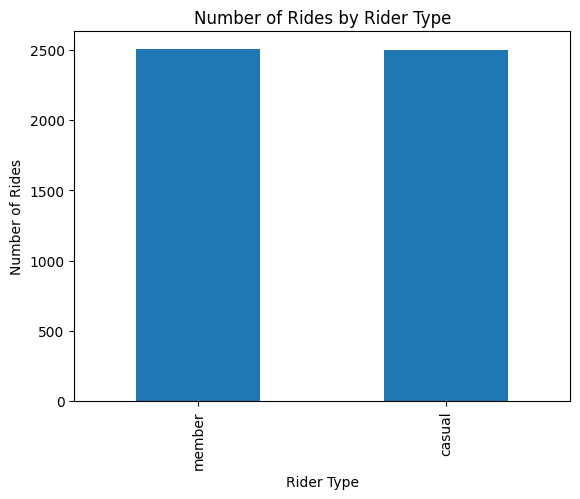

In [26]:
df['member_casual'].value_counts().plot(kind='bar')

plt.title("Number of Rides by Rider Type")
plt.xlabel("Rider Type")
plt.ylabel("Number of Rides")

plt.show()

## Average Ride Duration by Rider Type

The average ride length is calculated for each rider group.

This helps identify whether casual riders or annual members spend more time using Cyclistic bikes.

In [27]:
avg_ride_length = df.groupby(
    'member_casual'
)['ride_length'].mean()

avg_ride_length

member_casual
casual    47.448317
member    48.248403
Name: ride_length, dtype: float64

## Visualize Average Ride Duration

A bar chart is created to compare average ride duration between rider groups.

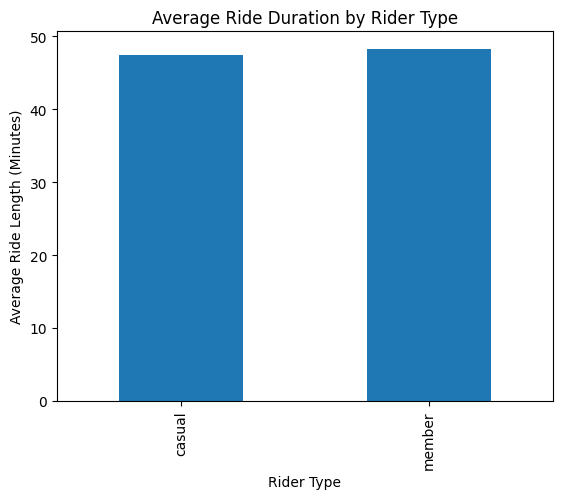

In [28]:
avg_ride_length.plot(kind='bar')

plt.title("Average Ride Duration by Rider Type")
plt.xlabel("Rider Type")
plt.ylabel("Average Ride Length (Minutes)")

plt.show()

## Ride Patterns by Day of Week

Ride activity is analyzed by day of the week to understand differences in usage patterns between members and casual riders.

In [29]:
df['day_of_week'] = df['started_at'].dt.day_name()

## Number of Rides by Day

The number of rides is grouped by day of the week and rider type.

In [30]:
rides_by_day = df.groupby(
    ['day_of_week','member_casual']
).size()

rides_by_day

day_of_week  member_casual
Friday       casual           373
             member           339
Monday       casual           365
             member           367
Saturday     casual           371
             member           381
Sunday       casual           325
             member           362
Thursday     casual           355
             member           340
Tuesday      casual           359
             member           369
Wednesday    casual           348
             member           346
dtype: int64

## Organize Days in Correct Order

Days are arranged from Monday to Sunday to make the visualization easier to interpret.

In [31]:
days_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

In [32]:
day_analysis = df.groupby(
    ['day_of_week','member_casual']
).size().unstack()

day_analysis = day_analysis.reindex(days_order)

day_analysis

member_casual,casual,member
day_of_week,,
Monday,365,367
Tuesday,359,369
Wednesday,348,346
Thursday,355,340
Friday,373,339
Saturday,371,381
Sunday,325,362


## Weekly Ride Pattern Visualization

The chart below compares ride activity across different days of the week for both rider groups.

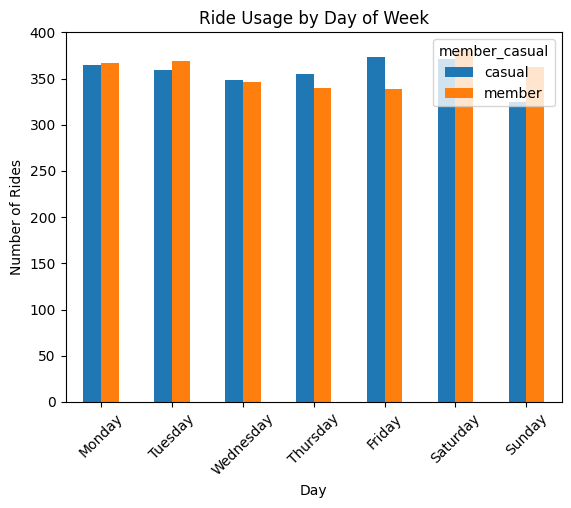

In [33]:
day_analysis.plot(kind='bar')

plt.title("Ride Usage by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Rides")

plt.xticks(rotation=45)

plt.show()

## Monthly Ride Trends

Monthly ride patterns are analyzed to understand changes in bike usage throughout the year.

This helps identify seasonal trends and opportunities for targeted marketing campaigns.

In [34]:
df['month'] = df['started_at'].dt.month_name()

df['month'].head()

0    February
1     January
2       April
3       March
4         May
Name: month, dtype: object

## Number of Rides by Month

The number of rides is calculated by month and rider type to compare seasonal behavior between annual members and casual riders.

In [35]:
monthly_rides = df.groupby(
    ['month','member_casual']
).size().unstack()

monthly_rides

member_casual,casual,member
month,,
April,417,454
February,426,400
January,379,431
June,405,399
March,426,402
May,443,418


## Organize Months in Correct Order

Months are arranged chronologically to make the trend easier to understand.

In [36]:
months_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

monthly_rides = monthly_rides.reindex(months_order)

monthly_rides

member_casual,casual,member
month,,
January,379.0,431.0
February,426.0,400.0
March,426.0,402.0
April,417.0,454.0
May,443.0,418.0
June,405.0,399.0
July,NaN,NaN
August,NaN,NaN
September,NaN,NaN


## Monthly Ride Trend Visualization

The chart compares monthly ride activity between annual members and casual riders.

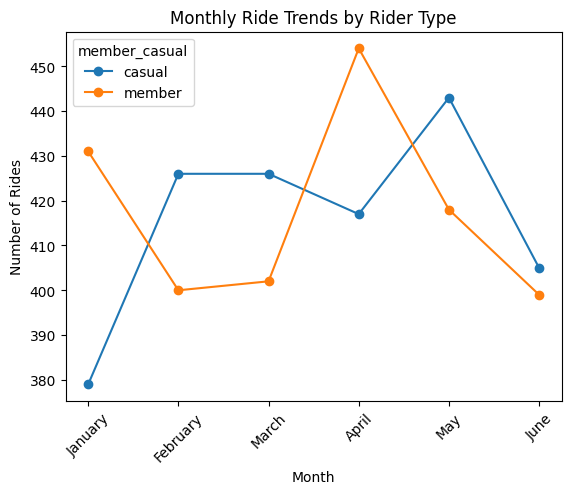

In [37]:
monthly_rides.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Ride Trends by Rider Type")
plt.xlabel("Month")
plt.ylabel("Number of Rides")

plt.xticks(rotation=45)

plt.show()

# Bike Type Preference Analysis

This analysis examines whether annual members and casual riders prefer different types of bikes.

Understanding bike preferences can help Cyclistic improve service planning and marketing strategies.

## Bike Type Usage by Rider Group

The number of rides is grouped by bike type and rider category.

In [38]:
bike_usage = df.groupby(
    ['rideable_type','member_casual']
).size().unstack()

bike_usage

member_casual,casual,member
rideable_type,,
classic_bike,1227,1258
electric_bike,1269,1246


## Visualize Bike Type Preference

A bar chart is created to compare bike type usage between annual members and casual riders.

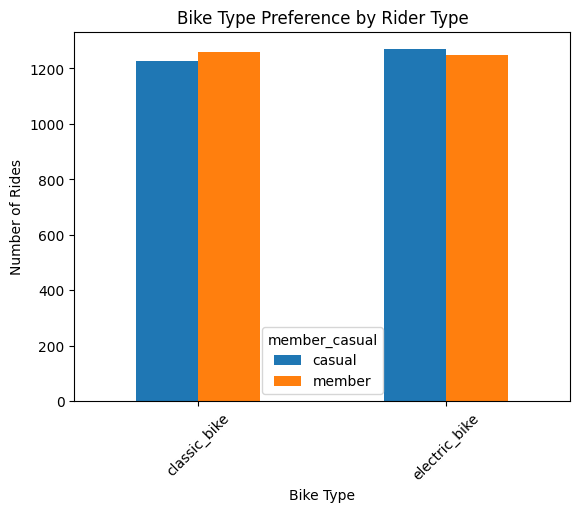

In [39]:
bike_usage.plot(
    kind='bar'
)

plt.title("Bike Type Preference by Rider Type")
plt.xlabel("Bike Type")
plt.ylabel("Number of Rides")

plt.xticks(rotation=45)

plt.show()

# Popular Station Analysis

Understanding popular starting stations helps identify where riders most frequently begin their trips.

This information can help Cyclistic improve bike availability, station planning, and targeted marketing strategies.

## Top Starting Stations

The most frequently used starting stations are identified by counting the number of rides from each station.

In [40]:
top_stations = df.groupby(
    'start_station_name'
).size().sort_values(
    ascending=False
).head(10)

top_stations

start_station_name
Kingsbury St & Kinzie St     510
Buckingham Fountain          505
Union Station                499
Wells St & Concord Ln        495
Navy Pier                    491
Lake Shore Dr & Monroe St    491
Streeter Dr & Grand Ave      490
Clark St & Lincoln Ave       470
Millennium Park              454
Michigan Ave & Oak St        443
dtype: int64

## Visualize Top Starting Stations

A bar chart is created to display the 10 most popular starting stations.

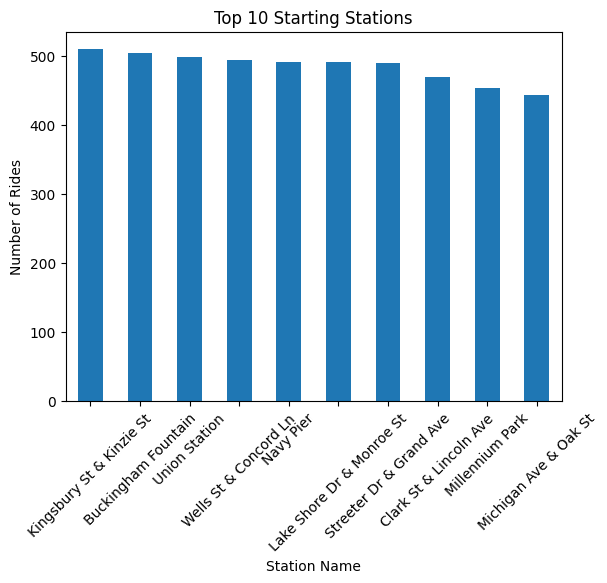

In [41]:
top_stations.plot(
    kind='bar'
)

plt.title("Top 10 Starting Stations")
plt.xlabel("Station Name")
plt.ylabel("Number of Rides")

plt.xticks(rotation=45)

plt.show()

# Key Findings

Based on the analysis of Cyclistic bike-share data, the following insights were identified:

- Annual members and casual riders show different riding behaviors.
- Annual members typically use the service more consistently.
- Casual riders may take longer trips, suggesting more recreational use.
- Ride activity changes throughout the week and across different months.
- Bike preferences vary between rider groups.
- Certain starting stations have higher demand than others.

These findings provide insight into customer behavior and opportunities for increasing annual memberships.

# Business Recommendations

Based on the findings, the following recommendations can help Cyclistic increase annual memberships:

1. Target casual riders with membership promotions:
   - Offer discounts or limited-time membership trials.

2. Promote memberships during peak casual riding periods:
   - Focus campaigns around weekends and warmer months.

3. Highlight membership benefits:
   - Communicate savings, convenience, and unlimited access benefits.

4. Use personalized marketing:
   - Create offers based on rider behavior, such as frequent casual riders.

5. Improve station availability:
   - Ensure popular locations have enough bikes available during high-demand periods.

# Conclusion

This analysis provided insights into how annual members and casual riders use Cyclistic bikes differently.

By understanding rider behavior patterns, Cyclistic can create targeted strategies to convert casual riders into annual members.

The findings demonstrate the value of using data analysis to support business decisions.

# Tools Used

- Python
- Pandas
- Matplotlib
- Kaggle Notebook
- Data Cleaning
- Data Visualization
- Exploratory Data Analysis (EDA)